<div style="background:linear-gradient(120deg,#0a2a5c,#1c5aa6);color:#fff;padding:22px 26px;border-radius:12px;border-bottom:5px solid #d49a2a;">
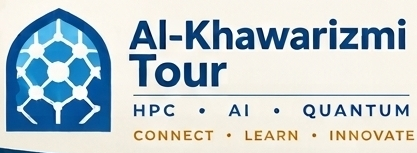
<p style="color:#ffd98e;letter-spacing:.14em;font-size:12px;font-weight:700;margin:12px 0 4px;">AL-KHAWARIZMI TOUR · ONLINE HACKATHON HPC &amp; AI · OCT 3 – NOV 7, 2026 · LECTURE 1 NOTEBOOK</p>
<h1 style="color:#fff;margin:4px 0 6px;border:none;">Data Quality &amp; Preprocessing — Beijing Air Quality · Hands-on &amp; Week-1 Team Challenge</h1>
<p style="color:#e6eef8;margin:0;">Part A: guided demos used during the lecture (slide references in each heading) · Part B: the week-long <b>Air-Quality Data Challenge</b></p>
<p style="color:#ffd98e;margin:10px 0 0;font-style:italic;">Connect · Learn · Innovate — Instructor: Dr. Rafik Borji</p></div>

## How to use this notebook

| Part | When | What |
|---|---|---|
| **A · Guided demos** (A1–A11) | during the 2-hour lecture | each demo matches a slide of the deck / a card of the speaker script |
| **B · Team challenge** (Tasks 1–6 + ★ bonus) | the whole week | fill in the `# TODO` cells, write your report, prepare your pitch |

**Dataset:** *Beijing Multi-Site Air Quality* — UCI Machine Learning Repository, dataset 501. Hourly PM2.5, PM10, SO2, NO2, CO, O3 (µg/m³) and TEMP, PRES, DEWP, RAIN, wind direction `wd`, wind speed `WSPM` at **12 stations**, **1 Mar 2013 – 28 Feb 2017**, **420,768 rows**, with real missing values (NA).
Reference: Zhang, S. et al. (2017) *Cautionary tales on air-quality improvement in Beijing*, Proc. R. Soc. A.

**Data access:** the notebook downloads the archive from UCI (≈ 8 MB) and caches it. If you already have the `PRSA_Data_*.csv` files, put them next to the notebook. Offline, a synthetic stand-in with the same columns is generated so the code still runs.

**Requirements:** Python ≥ 3.9, `numpy`, `pandas`, `matplotlib`, `scikit-learn ≥ 1.2`. Works in Jupyter, VS Code or Google Colab. Tip: on a laptop, run Part A first on `SAMPLE_STATIONS` (4 stations) and switch to all 12 for the challenge.

## 0 · Setup — set your team number first

In [ ]:
TEAM_ID = 1            # <-- your team number: it seeds YOUR version of the merged dataset
SEED = 1000 + TEAM_ID

import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": .3})
rng = np.random.default_rng(SEED)
import sklearn; print("scikit-learn", sklearn.__version__, "| team", TEAM_ID)

---
# Part A · Guided demos
## A1 · Load the 12 station files  *(slides 2 & 13)*

In [ ]:
import io, os, glob, ssl, zipfile, urllib.request

STATIONS = ["Aotizhongxin", "Changping", "Dingling", "Dongsi", "Guanyuan", "Gucheng", "Huairou",
            "Nongzhanguan", "Shunyi", "Tiantan", "Wanliu", "Wanshouxigong"]
WD = ["N", "NNE", "NE", "ENE", "E", "ESE", "SE", "SSE", "S", "SSW", "SW", "WSW", "W", "WNW", "NW", "NNW"]
POLLUTANTS = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
WEATHER = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
KEY = ["station", "year", "month", "day", "hour"]
URL = "https://archive.ics.uci.edu/static/public/501/beijing+multi+site+air+quality+data.zip"
CACHE = "beijing_air_quality_raw.csv.gz"

def _csvs_from_zip(blob):
    """The UCI archive contains a nested zip with one CSV per station -> read them all."""
    frames = []
    with zipfile.ZipFile(io.BytesIO(blob)) as z:
        for name in z.namelist():
            if name.lower().endswith(".zip"):
                frames += _csvs_from_zip(z.read(name))
            elif name.lower().endswith(".csv") and "PRSA_Data" in os.path.basename(name):
                frames.append(pd.read_csv(io.BytesIO(z.read(name))))
    return frames

def _download(url):
    try:
        return urllib.request.urlopen(url, timeout=180).read()
    except Exception:
        return urllib.request.urlopen(url, timeout=180, context=ssl._create_unverified_context()).read()

def synthetic_beijing(seed=0):
    """Offline stand-in with the same columns, 12 stations, seasonal/diurnal cycles and runs of missing values.
    Used ONLY if neither local files nor the UCI download are available."""
    r = np.random.default_rng(seed)
    t = pd.date_range("2013-03-01 00:00", "2017-02-28 23:00", freq="h")
    n, doy, hr = len(t), t.dayofyear.values, t.hour.values
    season = np.cos(2 * np.pi * (doy - 15) / 365.25)                 # +1 in mid-January (heating season)
    e = r.normal(0, 1, n); z = np.zeros(n)
    for i in range(1, n):                                            # regional stagnation index, AR(1)
        z[i] = 0.985 * z[i - 1] + 0.17 * e[i]
    frames = []
    for k, st in enumerate(STATIONS):
        urb = 1.0 if st in ["Dongsi", "Guanyuan", "Gucheng", "Nongzhanguan", "Tiantan", "Wanshouxigong", "Aotizhongxin", "Wanliu"] else 0.0
        TEMP = 13 - 15 * season + 4 * np.sin(2 * np.pi * (hr - 9) / 24) + r.normal(0, 2, n) - (1 - urb)
        DEWP = TEMP - np.clip(r.gamma(2, 4, n) - 3 * z, 0.5, 35)
        PRES = 1012 + 12 * season + r.normal(0, 3, n)
        WSPM = np.clip(r.gamma(2, 0.9, n) - 0.4 * z, 0, None)
        ang = (np.where(z < 0, 315, 180) + r.normal(0, 50, n)) % 360
        wd = np.array(WD)[np.round(ang / 22.5).astype(int) % 16]
        RAIN = np.where(r.random(n) < 0.03 * (1 - season), r.exponential(1.5, n), 0.0)
        logpm = 3.8 + 0.35 * season + 0.9 * z + 0.15 * urb + 0.2 * np.cos(2 * np.pi * (hr - 22) / 24) - 0.15 * WSPM + r.normal(0, .25, n)
        PM25 = np.clip(np.exp(logpm), 3, 900)
        PM10 = PM25 * (1.15 + r.gamma(2, 0.2, n))
        CO = np.clip(300 + 11 * PM25 * (1 + .3 * season) + r.normal(0, 150, n), 100, None)
        NO2 = np.clip(20 + .35 * PM25 ** .8 + 10 * urb + r.normal(0, 8, n), 2, None)
        SO2 = np.clip(3 + 25 * np.clip(season, 0, None) * np.exp(.5 * z) + r.normal(0, 3, n), 2, None)
        O3 = np.clip(10 + 60 * (1 - season) / 2 * 2 * np.clip(np.sin(2 * np.pi * (hr - 8) / 24), 0, None) - .2 * NO2 + r.normal(0, 10, n), 2, None)
        f = pd.DataFrame({"No": np.arange(1, n + 1), "year": t.year, "month": t.month, "day": t.day, "hour": hr,
                          "PM2.5": PM25, "PM10": PM10, "SO2": SO2, "NO2": NO2, "CO": CO, "O3": O3,
                          "TEMP": TEMP, "PRES": PRES, "DEWP": DEWP, "RAIN": RAIN, "wd": wd, "WSPM": WSPM, "station": st}).round(1)
        for c in POLLUTANTS + WEATHER + ["wd"]:                       # runs of missing values
            for s0 in r.choice(n, 25, replace=False):
                f.loc[s0:s0 + int(r.geometric(0.08)), c] = np.nan
        frames.append(f)
    return frames

def load_beijing():
    local = sorted(glob.glob("**/PRSA_Data_*.csv", recursive=True))
    if local:
        frames = [pd.read_csv(f) for f in local]; src = f"{len(local)} local station files"
    elif os.path.exists(CACHE):
        return pd.read_csv(CACHE)
    else:
        try:
            frames = _csvs_from_zip(_download(URL)); src = "UCI download"
        except Exception as e:
            print("UCI not reachable (", type(e).__name__, ")"); frames = []
        if not frames:
            frames = synthetic_beijing(); src = "SYNTHETIC offline stand-in"
    df = pd.concat(frames, ignore_index=True)
    if src == "UCI download":
        df.to_csv(CACHE, index=False)
    print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns from {src}")
    return df

raw = load_beijing()
raw["datetime"] = pd.to_datetime(raw[["year", "month", "day", "hour"]])
raw.head()

## A2 · The scenario: a careless merge + an untouched final year  *(slides 27 & 32)*
* **Test year** = 1 Mar 2016 – 28 Feb 2017 (the real data, untouched) — used **only in Task 6**.
* **Training years** = 1 Mar 2013 – 29 Feb 2016 → turned into your team's *merged export* with realistic merge errors.

In [ ]:
SPLIT = pd.Timestamp("2016-03-01")
train_raw = raw[raw["datetime"] < SPLIT].reset_index(drop=True)
test_year = raw[raw["datetime"] >= SPLIT].reset_index(drop=True)
print(f"training years: {len(train_raw):,} rows | test year: {len(test_year):,} rows")

## A3 · Generate your team's merged export
The function reproduces problems of a careless multi-station merge. **Treat it as a black box during the challenge** — your job is to *discover* the problems from the data.

In [ ]:
def make_dirty(df, seed):
    r = np.random.default_rng(seed)
    d = df.drop(columns=["datetime"]).copy()
    n = len(d)
    st_unit, st_tz, st_stuck = r.choice(STATIONS, 3, replace=False)
    # 1) consistency: station-name variants and lower-case wind directions
    v = r.random(n)
    d.loc[v < .05, "station"] = d.loc[v < .05, "station"].str.upper()
    d.loc[(v >= .05) & (v < .10), "station"] = d.loc[(v >= .05) & (v < .10), "station"].str.lower() + " "
    w = r.random(n) < .02
    d.loc[w, "wd"] = d.loc[w, "wd"].str.lower()
    stn = d["station"].str.strip().str.title()
    # 2) accuracy: one station exported CO in mg/m3 during 2014
    m = (stn == st_unit) & (d["year"] == 2014)
    d.loc[m, "CO"] = d.loc[m, "CO"] / 1000
    # 3) timeliness: one station exported in UTC during 2015 (8 h behind Beijing time)
    m = (stn == st_tz) & (d["year"] == 2015)
    dt = pd.to_datetime(d.loc[m, ["year", "month", "day", "hour"]]) - pd.Timedelta(hours=8)
    d.loc[m, "year"], d.loc[m, "month"], d.loc[m, "day"], d.loc[m, "hour"] = dt.dt.year, dt.dt.month, dt.dt.day, dt.dt.hour
    # 4) validity: stuck PM2.5 sensor (flat lines), sentinel codes, PM2.5/PM10 column swap
    idx = np.flatnonzero((stn == st_stuck).values)
    for s0 in r.choice(idx[:-80], 8, replace=False):
        L = int(r.integers(24, 73)); rows = d.index[s0:s0 + L]
        d.loc[rows, "PM2.5"] = d.loc[rows[0], "PM2.5"]
    for c in ["TEMP", "PRES"]:
        d.loc[r.random(n) < .002, c] = -999
    sw = r.random(n) < .003
    d.loc[sw, ["PM2.5", "PM10"]] = d.loc[sw, ["PM10", "PM2.5"]].values
    # 5) completeness: extra random logger drop-outs in NO2
    d.loc[r.random(n) < .03, "NO2"] = np.nan
    # 6) uniqueness: one station-month re-uploaded (slightly different O3) + scattered exact duplicates
    s_dup = r.choice(STATIONS); y_dup, m_dup = 2014, int(r.integers(1, 13))
    re = d[(stn == s_dup) & (d["year"] == y_dup) & (d["month"] == m_dup)].copy()
    re["O3"] = re["O3"] + 1
    d = pd.concat([d, re, d.sample(frac=.005, random_state=seed)], ignore_index=True)
    return d.sample(frac=1, random_state=seed).reset_index(drop=True)

dirty = make_dirty(train_raw, SEED)
dirty.to_csv(f"beijing_merged_team{TEAM_ID}.csv.gz", index=False)
print(f"merged export: {dirty.shape[0]:,} rows -> beijing_merged_team{TEAM_ID}.csv.gz")
dirty.head()

## A4 · First look  *(slides 11, 13 & 14)*

In [ ]:
df = dirty.copy()
print("shape:", df.shape, "\n")
print(df.dtypes, "\n")
print("fraction missing:\n", df.isna().mean().round(4).sort_values(ascending=False), "\n")
print("duplicate station-hours:", df.duplicated(subset=KEY).sum())
print("station labels:", df["station"].nunique(), "distinct (expected 12)")

In [ ]:
# mean vs median per station -> skew; min / max -> impossible values
df.groupby(df["station"].str.strip().str.title())[["PM2.5", "CO", "TEMP", "PRES"]].agg(["mean", "median", "min", "max"]).round(1)

In [ ]:
# missing-value matrix for one station (rows = hours in time order)
one = df[df["station"] == "Dongsi"].sort_values(["year", "month", "day", "hour"])
plt.figure(figsize=(10, 3))
plt.imshow(one[POLLUTANTS + WEATHER].isna().values.T, aspect="auto", interpolation="nearest", cmap="Blues")
plt.yticks(range(len(POLLUTANTS + WEATHER)), POLLUTANTS + WEATHER); plt.xlabel("hour index"); plt.grid(False)
plt.title("Dongsi — missing values (dark) over time: random or in runs?"); plt.show()

In [ ]:
# the single most useful plot: a time series per station
one_dt = pd.to_datetime(one[["year", "month", "day", "hour"]])
plt.plot(one_dt, one["PM2.5"], lw=.4); plt.yscale("log"); plt.title("Dongsi PM2.5 (log scale)"); plt.show()

## A5 · Consistency: canonical labels  *(slide 21)*

In [ ]:
print(df["station"].value_counts().head(15))
canon = df["station"].str.strip().str.title()
print("\nafter strip + title:", canon.nunique(), "stations")
print("wind directions:", sorted(df["wd"].dropna().unique()))

## A6 · Outliers, stuck sensors and physics checks  *(slides 19 & 20)*

In [ ]:
num = df.copy()
checks = {
    "PM2.5 > PM10 (impossible)": int((num["PM2.5"] > num["PM10"]).sum()),
    "negative concentrations":   int((num[POLLUTANTS] < 0).sum().sum()),
    "sentinel -999 codes":       int((num[POLLUTANTS + WEATHER] == -999).sum().sum()),
    "PRES outside 950-1060 hPa": int(((num["PRES"] < 950) | (num["PRES"] > 1060)).sum()),
}
pd.Series(checks, name="rows")

In [ ]:
def hampel_flags(s, window=25, k=3.0):
    med = s.rolling(window, center=True, min_periods=5).median()
    mad = (s - med).abs().rolling(window, center=True, min_periods=5).median()
    return (s - med).abs() > k * 1.4826 * mad

def stuck_flags(s, hours=12):
    return s.rolling(hours).std() == 0

res = {}
for st, g in df.assign(station=canon).sort_values(["year", "month", "day", "hour"]).groupby("station"):
    res[st] = {"Hampel spikes": int(hampel_flags(g["PM2.5"]).sum()), "stuck >= 12 h": int(stuck_flags(g["PM2.5"]).sum())}
pd.DataFrame(res).T.sort_values("stuck >= 12 h", ascending=False)

## A7 · Imputation study — single hours vs 24-hour gaps  *(slide 18)*
We hide values we **know** (clean reference = the original training years, demo only) and measure the RMSE of each imputer.

In [ ]:
from sklearn.impute import KNNImputer
piv = train_raw.pivot_table(index="datetime", columns="station", values="NO2")   # hours x stations
target_st = "Dongsi"
truth = piv[target_st]
known = np.flatnonzero(truth.notna().values)

def make_mask(kind):
    m = np.zeros(len(truth), bool)
    if kind == "single hours":
        m[rng.choice(known, len(known) // 10, replace=False)] = True
    else:                                                    # 24-h blocks
        for s0 in rng.choice(known[:-30], 150, replace=False):
            m[s0:s0 + 24] = True
        m &= truth.notna().values
    return m

def evaluate(mask):
    s = truth.mask(mask)
    others = piv.drop(columns=target_st)
    nb = others.mean(axis=1)
    cand = {
        "mean": s.fillna(s.mean()),
        "median": s.fillna(s.median()),
        "time interpolation": s.interpolate(method="time", limit_direction="both"),
        "neighbour stations": s.fillna(nb + (s - nb).mean()),
        "KNN across stations": pd.Series(KNNImputer(n_neighbors=5).fit_transform(piv.assign(**{target_st: s}))[:, list(piv.columns).index(target_st)], index=s.index),
    }
    return {k: np.sqrt(np.mean((v.fillna(s.mean()).values[mask] - truth.values[mask]) ** 2)) for k, v in cand.items()}

t0 = time.perf_counter()
study = pd.DataFrame({kind: evaluate(make_mask(kind)) for kind in ["single hours", "24-h blocks"]}).round(2)
print(f"({time.perf_counter() - t0:.1f} s)  RMSE of NO2 in µg/m³ — lower is better")
study

## A8 · Skewness and transformations  *(slides 12 & 25)*

In [ ]:
from sklearn.preprocessing import PowerTransformer
vals = train_raw[["PM2.5", "SO2", "CO", "NO2", "O3", "WSPM"]].dropna()
print("skewness raw:\n", vals.skew().round(2))
print("\nskewness after log1p:\n", np.log1p(vals).skew().round(2))
fig, ax = plt.subplots(1, 2, figsize=(11, 3.2))
ax[0].hist(vals["PM2.5"], bins=80); ax[0].set_title("PM2.5 — raw")
ax[1].hist(np.log1p(vals["PM2.5"]), bins=80, color="#d49a2a"); ax[1].set_title("PM2.5 — log1p")
plt.tight_layout(); plt.show()

## A9 · Multicollinearity — VIF  *(slide 22)*

In [ ]:
def vif(frame):
    X = (frame - frame.mean()) / frame.std()
    out = {}
    for c in X.columns:
        Aa = np.column_stack([np.ones(len(X)), X.drop(columns=c).values])
        coef, *_ = np.linalg.lstsq(Aa, X[c].values, rcond=None)
        resid = X[c].values - Aa @ coef
        out[c] = 1 / max(1 - (1 - (resid ** 2).sum() / ((X[c] - X[c].mean()) ** 2).sum()), 1e-12)
    return pd.Series(out, name="VIF").sort_values(ascending=False).round(2)

vif(train_raw[["SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "WSPM"]].dropna().sample(50_000, random_state=0))

## A10 · Leakage demo — random split vs time split  *(slides 27 & 28)*
Same model, same data, two ways of splitting. The random split lets near-identical neighbouring hours sit on both sides.

In [ ]:
def add_features(d):
    """Model-ready features: datetime, cyclical time, circular wind direction, dew-point depression."""
    d = d.copy()
    d["datetime"] = pd.to_datetime(d[["year", "month", "day", "hour"]], errors="coerce")
    d["hour_sin"], d["hour_cos"] = np.sin(2 * np.pi * d["hour"] / 24), np.cos(2 * np.pi * d["hour"] / 24)
    d["month_sin"], d["month_cos"] = np.sin(2 * np.pi * d["month"] / 12), np.cos(2 * np.pi * d["month"] / 12)
    d["dow"] = d["datetime"].dt.dayofweek
    ang = d["wd"].map({w: i * 2 * np.pi / 16 for i, w in enumerate(WD)})
    d["wd_sin"], d["wd_cos"] = np.sin(ang), np.cos(ang)
    d["TD_dep"] = d["TEMP"] - d["DEWP"]                      # dew-point depression (humidity)
    d["rain_flag"] = (d["RAIN"] > 0).astype(float).where(d["RAIN"].notna())
    return d

# Virtual PM2.5 sensor: PM10 is deliberately EXCLUDED (same instrument -> down at the same time)
NUM_FEATS = ["SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM", "TD_dep", "rain_flag",
             "hour_sin", "hour_cos", "month_sin", "month_cos", "dow", "wd_sin", "wd_cos"]
CAT_FEATS = ["station"]
TARGET = "PM2.5"

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import KFold, TimeSeriesSplit, cross_val_score

def make_pipeline(model):
    num = Pipeline([("impute", SimpleImputer(strategy="median", add_indicator=True)), ("scale", StandardScaler())])
    cat = Pipeline([("impute", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))])
    prep = ColumnTransformer([("num", num, NUM_FEATS), ("cat", cat, CAT_FEATS)], sparse_threshold=0)
    return Pipeline([("prep", prep), ("model", model)])

ref = add_features(train_raw.drop(columns=["datetime"])).dropna(subset=[TARGET]).sort_values("datetime")
ref = ref.iloc[::3]                                   # every 3rd hour keeps the demo fast
X_ref, y_ref = ref[NUM_FEATS + CAT_FEATS], ref[TARGET]
hgb = make_pipeline(HistGradientBoostingRegressor(max_iter=200, random_state=0))
for name, cv in [("random KFold", KFold(5, shuffle=True, random_state=0)), ("TimeSeriesSplit", TimeSeriesSplit(5))]:
    s = cross_val_score(hgb, X_ref, y_ref, cv=cv, scoring="neg_root_mean_squared_error")
    print(f"{name:16s} CV RMSE = {-s.mean():6.2f} ± {s.std():.2f} µg/m³")

## A11 · Template: a leak-free, time-aware pipeline  *(slide 29)*
`make_pipeline` above is the template you adapt in Task 5. Everything that *learns* (imputers, scalers, encoders) lives **inside** it, so it is re-fitted in every fold.

---
# Part B · Week-1 Team Challenge — *The Air-Quality Data Challenge*

<div style="border:2px solid #d49a2a;background:#fbf1dc;border-radius:10px;padding:12px 18px;color:#14203a;">
<b style="color:#8f5f0c;font-size:15px;">Scenario</b><br>The city’s environmental agency merged the exports of its <b>12 monitoring stations</b> (1 Mar 2013 – 29 Feb 2016) for an AI project. On top of the real gaps, the merge introduced errors. Your file <code>beijing_merged_team&lt;N&gt;.csv.gz</code> (created in A3) is your team’s version. <br><b>Goal:</b> deliver a documented, leak-free pipeline for a <b>virtual PM2.5 sensor</b> — estimate PM2.5 from gases, weather, time and station, <b>without PM10</b> (same instrument, down at the same time) — and <b>prove with numbers</b> how much your data work improves it on the untouched test year.</div>

| # | Task | Points |
|---|---|---|
| 1 | Data-quality audit (six dimensions, gap lengths, missingness by station) | 15 |
| 2 | Consistency, validity & timeliness fixes | 15 |
| 3 | Imputation study (≥ 3 imputers incl. one time-aware) | 15 |
| 4 | Outliers: stuck sensors & spikes vs real episodes; transformations | 10 |
| 5 | Leak-free pipeline + `TimeSeriesSplit` CV | 15 |
| 6 | Impact study on the test year | 20 |
| ★ | HPC bonus: parallel per-station cleaning | +10 |
|   | 1-page report + 5-min pitch | 10 |

**Rules:** `test_year` only in Task 6 · justify every decision in one line · keep `SEED` fixed · start from `beijing_merged_team<N>.csv.gz`, not from `train_raw`.

**Suggested plan:** Days 1–2 Task 1 · Days 3–4 Tasks 2–5 · Day 5 Task 6 (+ bonus) · Days 6–7 report & pitch.

**Hint — what kinds of problems to look for:** label variants, a unit mix-up, a time-zone shift, re-uploaded data, stuck sensors, sentinel codes, physically impossible values, extra drop-outs. *Which station, which column, which period? That is for you to find.*

## Task 1 · Data-quality audit (15 pts)

In [ ]:
df = pd.read_csv(f"beijing_merged_team{TEAM_ID}.csv.gz")

# TODO 1a completeness: % missing per column AND per station; gap-length distribution (see slide 17 code)
# TODO 1b uniqueness: duplicate station-hours (KEY); are duplicates identical or slightly different?
# TODO 1c validity: PM2.5 > PM10, negative values, -999 codes, implausible PRES / TEMP
# TODO 1d accuracy: station medians of each pollutant on a log scale — any station x1000 off? which years?
# TODO 1e timeliness: hour of the mean daily TEMP / O3 peak per station and year — any station shifted?
# TODO 1f consistency: raw station and wd labels

In [ ]:
issue_log = pd.DataFrame(columns=["dimension", "station", "column", "period", "problem", "rows affected", "fix", "justification"])
# issue_log.loc[len(issue_log)] = ["validity", "all", "TEMP", "all", "-999 sentinel", 123, "set to NaN", "not a measurement"]
issue_log

## Task 2 · Consistency, validity & timeliness fixes (15 pts)
Write **one function** `clean_basic(df)` you could apply to next month's export. It should at least: canonicalise `station` and `wd`; fix the unit problem; undo the time-zone shift; set sentinel codes and impossible values to NaN (or repair the swap); flag stuck-sensor runs as NaN; resolve duplicate station-hours; build `datetime`; sort by station and time.

In [ ]:
def clean_basic(d):
    d = d.copy()
    # TODO: station -> canonical names in STATIONS ; wd -> upper-case compass points in WD
    # TODO: unit fix (which station / years? multiply by 1000?)
    # TODO: time-zone fix (+8 h for the affected station / period) BEFORE removing duplicates
    # TODO: -999 -> NaN ; PM2.5 > PM10 -> swap back or NaN (justify)
    # TODO: stuck runs (rolling std == 0 for >= 12 h) -> NaN
    # TODO: duplicates on KEY -> keep one (which one? why?)
    d["datetime"] = pd.to_datetime(d[["year", "month", "day", "hour"]], errors="coerce")
    return d.sort_values(["station", "datetime"]).reset_index(drop=True)

df_clean = clean_basic(df)
print(f"{len(df):,} -> {len(df_clean):,} rows | stations: {df_clean['station'].nunique()}")

## Task 3 · Imputation study (15 pts)
Using **your cleaned data**, extend A7: compare ≥ 3 imputers (at least one time-aware, e.g. limited interpolation, neighbour-station, seasonal-hourly profile) for **two** pollutants, with both single-hour and 24-h masks. Choose a strategy per gap length and justify it.

In [ ]:
# TODO

## Task 4 · Outliers & transformations (10 pts)
Classify flagged points as **error** (stuck, impossible, code) vs **real episode** (e.g. Spring Festival fireworks, winter smog). Show at least one example of each on a time plot. Report skewness before/after your transform.

In [ ]:
# TODO

## Task 5 · Leak-free pipeline + TimeSeriesSplit CV (15 pts)
Use `add_features` and adapt `make_pipeline` (A10). Report 5-fold `TimeSeriesSplit` RMSE ± sd for the virtual sensor on `df_clean` (sorted by `datetime`). Try at least two preprocessing variants (e.g. with/without missing indicators, log-target via `TransformedTargetRegressor`).

In [ ]:
data5 = add_features(df_clean.drop(columns=["datetime"])).dropna(subset=[TARGET]).sort_values("datetime")
X5, y5 = data5[NUM_FEATS + CAT_FEATS], data5[TARGET]
# TODO: scores = cross_val_score(make_pipeline(...), X5, y5, cv=TimeSeriesSplit(5), scoring="neg_root_mean_squared_error", n_jobs=-1)

## Task 6 · Impact study — does data quality matter? (20 pts)
Train the **same model** two ways and score both on the **same complete-case rows of the test year**:
1. **Naive:** the merged export as-is (features built, rows with missing values dropped, raw labels).
2. **Yours:** `clean_basic` + your imputation + your pipeline.
Report RMSE, MAE, R², a predicted-vs-actual plot and the error by station. Explain the difference.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
def scores(y, p): return {"RMSE": np.sqrt(mean_squared_error(y, p)), "MAE": mean_absolute_error(y, p), "R2": r2_score(y, p)}

test_f = add_features(test_year.drop(columns=["datetime"])).dropna(subset=NUM_FEATS + CAT_FEATS + [TARGET])

# 1) naive baseline (provided)
naive = add_features(df).dropna(subset=NUM_FEATS + CAT_FEATS + [TARGET])
naive_model = make_pipeline(HistGradientBoostingRegressor(max_iter=300, random_state=0)).fit(naive[NUM_FEATS + CAT_FEATS], naive[TARGET])
res_naive = scores(test_f[TARGET], naive_model.predict(test_f[NUM_FEATS + CAT_FEATS]))

# 2) yours — TODO: fit your pipeline on your cleaned + imputed training data, predict test_f
res_yours = {"RMSE": np.nan, "MAE": np.nan, "R2": np.nan}
pd.DataFrame({"naive (merged export)": res_naive, "yours (cleaned)": res_yours}).T.round(3)

## ★ HPC bonus (+10 pts) — parallel per-station cleaning
The 12 stations are independent: run `clean_basic` + your imputation **per station** with `joblib.Parallel` (or Dask) and compare wall-time for 1, 2, 4 … workers. Report the speed-up $S_p=T_1/T_p$, efficiency $E_p=S_p/p$ and the dominant step.

In [ ]:
from joblib import Parallel, delayed
def clean_one_station(g):
    return clean_basic(g)            # TODO: + your imputation

groups = [g for _, g in df.groupby(df["station"].str.strip().str.title())]
# for p in [1, 2, 4, -1]:
#     t0 = time.perf_counter(); out = Parallel(n_jobs=p)(delayed(clean_one_station)(g) for g in groups)
#     print(p, time.perf_counter() - t0)

## Export for Lecture 2
Save your cleaned (and imputed) training years — it is the **input of the Week-2 AI Methods Shoot-out**.

In [ ]:
# df_clean.drop(columns=["datetime"]).to_csv(f"beijing_clean_team{TEAM_ID}.csv.gz", index=False)

## Report template (1 page)
1. **Findings** — the issue log (dimension · station · column · period · problem · rows · fix · why).
2. **Key decisions** — imputation per gap length (Task 3 numbers), outlier policy, transforms, dropped rows and possible bias (MNAR in smog?).
3. **Impact** — naive vs cleaned test-year RMSE / MAE / R² and one plot.
4. **Lessons** — what would you ask the agency to change in how stations export data?
5. *(bonus)* HPC timings and speed-up.

<div style="background:linear-gradient(120deg,#0a2a5c,#1c5aa6);color:#e6eef8;padding:14px 22px;border-radius:10px;border-top:4px solid #d49a2a;margin-top:10px;">
<b style="color:#ffd98e;">Al-Khawarizmi Tour · Online Hackathon HPC &amp; AI</b> · Oct 3 – Nov 7, 2026 · 100% online<br>
<i>From the past to the future… Science without borders. Your ideas. A bigger tomorrow.</i> · © 2026 Dr. Rafik Borji</div>